# 13. Three-Dimensional Tidal Maps

Notebook 9 built a homogeneous, strongly dissipative Io and mapped its secular tidal heating for one orbit. This notebook uses the same world to show how that map changes with eccentricity, spin, and obliquity, and then maps the time-resolved response: the stress through one orbit, the largest tension an orbit produces, the stress-strain loop where dissipation appears, and the surface displacement.

The maps are drawn by `plot_map` and `make_map_axes` from `TidalPy.Utilities_x.graphics_x`. They use cartopy's projections when cartopy is installed, which is part of the optional `graphics` extra, and matplotlib's Mollweide projection otherwise.

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

from TidalPy.constants import G
from TidalPy.Material_x.eos.material_eos import ConstantDensityEOS
from TidalPy.rheology_x import Maxwell
from TidalPy.structures_x.layers.physics import PhysicsLayer
from TidalPy.structures_x.worlds.layered import LayeredWorld
from TidalPy.Tides_x.classes import make_tide
from TidalPy.Utilities_x.graphics_x import make_map_axes, plot_map
from TidalPy.viscosity_x import make_viscosity

R = 1.8216e6
M = 8.9319e22
RHO = M / (4.0 / 3.0 * np.pi * R**3)
M_JUP = 1.898e27
A_IO = 4.217e8
E_IO = 0.0041
N_MOTION = np.sqrt(G * M_JUP / A_IO**3)
PERIOD = 2.0 * np.pi / N_MOTION   # Orbital period [s]


def build_io(shear_viscosity):
    """The homogeneous Maxwell Io of notebook 9 with a chosen shear viscosity [Pa s]."""
    world = LayeredWorld("Io", R, M)
    mantle = PhysicsLayer("mantle", 0, 0.0, R, M)
    mantle.set_eos(ConstantDensityEOS(
        reference_density=RHO, shear_modulus_static=60.0e9, bulk_modulus_static=200.0e9))
    mantle.set_shear_viscosity(make_viscosity("constant", {"reference_viscosity_pas": shear_viscosity}))
    mantle.set_bulk_viscosity(make_viscosity("constant", {"reference_viscosity_pas": 1.0e30}))
    mantle.set_shear_rheology(Maxwell())
    mantle.set_bulk_rheology(Maxwell())
    world.add_layer(mantle)
    world.set_tide_model(make_tide("rheology"))
    world.set_tide_config(min_degree_l=2, max_degree_l=2, eccentricity_truncation=2, obliquity_truncation=0)
    world.solve_eos(G_to_use=G, temperature=1500.0, verbose=False)
    return world


io = build_io(1.0e15)
ORBIT = (N_MOTION, N_MOTION, E_IO, 0.0, A_IO, M_JUP)   # (n, spin, e, obliquity, a, host mass)

longitudes = np.linspace(0.0, 2.0 * np.pi, 121)       # [rad]
colatitudes = np.linspace(0.02, np.pi - 0.02, 61)     # [rad]
equator = np.argmin(np.abs(colatitudes - 0.5 * np.pi))
surface = 0.99 * R                                    # Just below the surface [m]
print("Io built and EOS solved:", io.eos_solved)

Io built and EOS solved: True


## Heating Across Orbital Configurations

The world's tide config sets which tidal modes enter the calculation: the degree range and the eccentricity and obliquity truncation levels. The orbital state passed to each call sets the eccentricity, spin, and obliquity themselves. The four maps below show the secular heating just below the surface, each on its own log scale.

Synchronous, e = 0.0041            strongest 4.69e-06 W/m^3, weakest 1.73e-07 W/m^3, north-south difference 1e-15 of the peak
Synchronous, e = 0.1               strongest 2.83e-03 W/m^3, weakest 1.11e-04 W/m^3, north-south difference 1e-15 of the peak
Spin = 1.2 n, e = 0.0041           strongest 2.22e-02 W/m^3, weakest 3.43e-03 W/m^3, north-south difference 1e-15 of the peak


Synchronous, obliquity = 0.1 rad   strongest 4.47e-04 W/m^3, weakest 1.37e-06 W/m^3, north-south difference 2e-01 of the peak


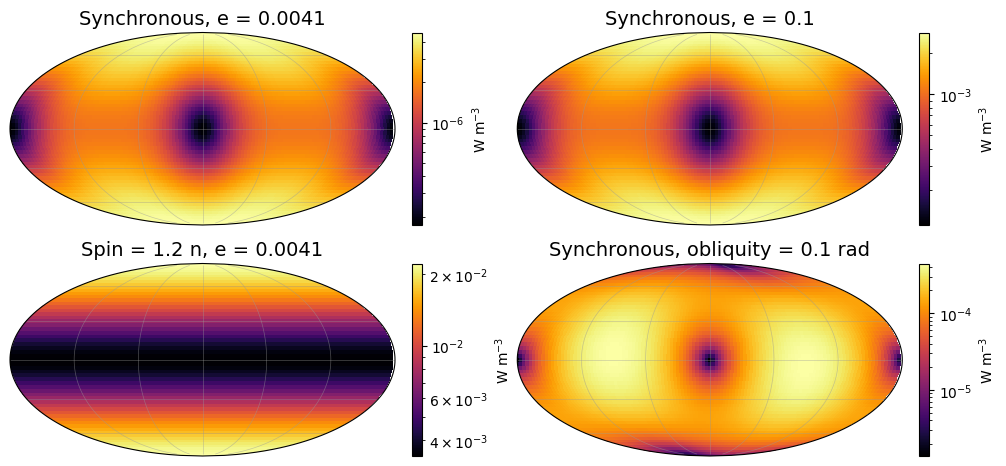

In [2]:
cases = [
    ("Synchronous, e = 0.0041", 2, 0, (N_MOTION, N_MOTION, E_IO, 0.0)),
    ("Synchronous, e = 0.1", 10, 0, (N_MOTION, N_MOTION, 0.1, 0.0)),
    ("Spin = 1.2 n, e = 0.0041", 2, 0, (N_MOTION, 1.2 * N_MOTION, E_IO, 0.0)),
    ("Synchronous, obliquity = 0.1 rad", 2, 2, (N_MOTION, N_MOTION, E_IO, 0.1)),
]

figure, axes = make_map_axes(nrows=2, ncols=2, figure_size=(12.0, 5.5))
for axis, (label, eccentricity_truncation, obliquity_truncation, state) in zip(axes.flat, cases):
    # Truncation levels high enough for the eccentricity and obliquity of this case
    io.set_tide_config(min_degree_l=2, max_degree_l=2, eccentricity_truncation=eccentricity_truncation,
                       obliquity_truncation=obliquity_truncation)
    heating = io.calc_3d_tides(*state, A_IO, M_JUP, radii=np.array([surface]), colatitudes=colatitudes,
                               longitudes=longitudes)["heating"][0]
    plot_map(longitudes, colatitudes, heating, axis=axis, log_scale=True, title=label, colorbar_label="W m$^{-3}$")
    print(f"{label:34} strongest {heating.max():.2e} W/m^3, weakest {heating.min():.2e} W/m^3, "
          f"north-south difference {np.abs(heating - heating[::-1]).max() / heating.max():.0e} of the peak")
plt.show()

# Back to the settings of notebook 9 for the rest of this notebook
io.set_tide_config(min_degree_l=2, max_degree_l=2, eccentricity_truncation=2, obliquity_truncation=0)

The two synchronous maps share one pattern: the heating is weakest on the equator at the sub-host and anti-host meridians (0 and 180 degrees) and strongest toward the poles. Raising the eccentricity from 0.0041 to 0.1 scales it by about 600, close to the square of the eccentricity ratio, since the heating goes as the square of the tidal forcing.

At a spin of 1.2 times the mean motion, the largest tidal mode, which is static at synchronous rotation, oscillates in the rotating frame. The heating becomes nearly 5000 times stronger. It also stops depending on longitude: waves with different longitude structure no longer share a frequency, so their cross terms average out over time.

Obliquity adds modes of order 1 in longitude. They raise the equatorial heating around 90 and 270 degrees and break the north-south symmetry, with the two hemispheres differing by up to 20 percent of the peak.

## Stress Through an Orbit

`calc_3d_stress_strain` returns the instantaneous stress [Pa] and strain on a radius, colatitude, longitude, and time grid, with the six tensor components on the last axis in the order given by `components`. Here it samples one orbit, starting at periapse, at 24 times just below the surface. The maps show the north-south normal stress at four of them, on one color scale. Tension is positive.

components: ('rr', 'theta_theta', 'phi_phi', 'r_theta', 'r_phi', 'theta_phi')
largest magnitude of each component over the orbit [kPa]: [ 4.4 82.2 82.1  3.   4.  77.1]


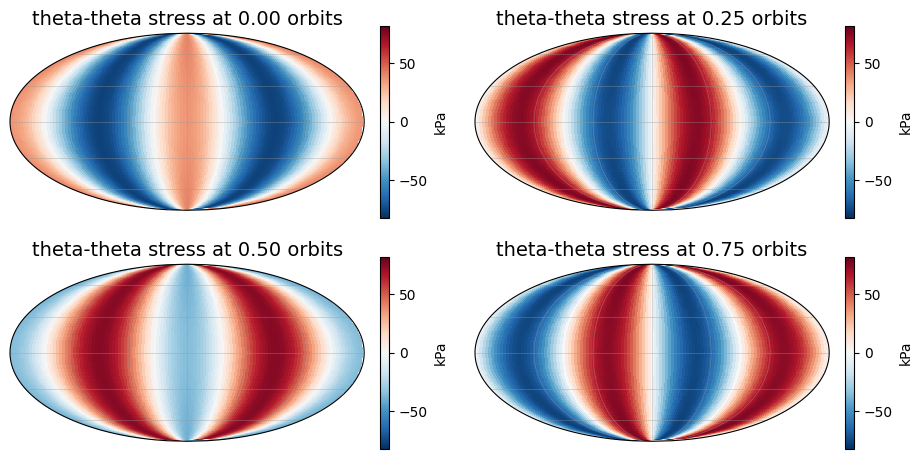

In [3]:
times = np.linspace(0.0, PERIOD, 24, endpoint=False)   # One orbit from periapse [s]
tensors = io.calc_3d_stress_strain(*ORBIT, radii=[surface], colatitudes=colatitudes, longitudes=longitudes,
                                   times=times)
stress = tensors["stress"][0]   # (colatitude, longitude, time, component) [Pa]
print("components:", tensors["components"])
print("largest magnitude of each component over the orbit [kPa]:",
      np.round(np.abs(stress).max(axis=(0, 1, 2)) / 1.0e3, 1))

theta_theta = stress[..., 1] / 1.0e3   # [kPa]
limit = np.abs(theta_theta).max()
figure, axes = make_map_axes(nrows=2, ncols=2, figure_size=(11.0, 5.5))
for axis, time_index in zip(axes.flat, (0, 6, 12, 18)):
    plot_map(longitudes, colatitudes, theta_theta[:, :, time_index], axis=axis, value_limits=(-limit, limit),
             colormap="RdBu_r", title=f"theta-theta stress at {times[time_index] / PERIOD:.2f} orbits",
             colorbar_label="kPa")
plt.show()

The radial and radial-shear components stay below 5 kPa, against about 80 kPa for the horizontal ones. The surface is free of traction, so the stress just below it is nearly horizontal. The pattern changes shape through the orbit and reverses sign after half an orbit.

## Largest Tensile Stress

Studies of tidal fracturing ask for the largest tension a point experiences during an orbit. The principal stresses are the eigenvalues of the stress tensor, so the largest eigenvalue at each point and time is the largest tension there, and its maximum over the orbit gives a single map.

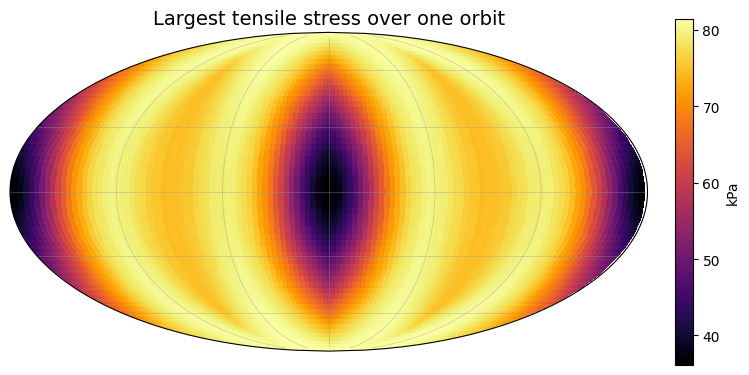

weakest 36 kPa (equator at longitude 0: 36 kPa), strongest 82 kPa (equator at longitude 90: 75 kPa, north pole: 81 kPa)


In [4]:
rr, tt, pp, rt, rp, tp = (stress[..., index] for index in range(6))
tensor = np.stack([
    np.stack([rr, rt, rp], axis=-1),
    np.stack([rt, tt, tp], axis=-1),
    np.stack([rp, tp, pp], axis=-1)], axis=-2)   # (colatitude, longitude, time, 3, 3)
largest_tension = np.linalg.eigvalsh(tensor)[..., -1].max(axis=-1) / 1.0e3   # Largest over the orbit [kPa]

plot_map(longitudes, colatitudes, largest_tension, title="Largest tensile stress over one orbit", colorbar_label="kPa")
plt.show()
print(f"weakest {largest_tension.min():.0f} kPa (equator at longitude 0: {largest_tension[equator, 0]:.0f} kPa), "
      f"strongest {largest_tension.max():.0f} kPa (equator at longitude 90: {largest_tension[equator, 30]:.0f} kPa, "
      f"north pole: {largest_tension[0, 0]:.0f} kPa)")

The largest tension over the orbit is weakest, about 36 kPa, on the equator at the sub-host and anti-host meridians. It reaches 75 kPa on the equator at 90 degrees of longitude and 81 kPa at the poles.

## Where Dissipation Appears

Over an orbit each stress component averages to zero, even in this strongly dissipative mantle. Dissipation appears instead as a lag of the strain behind the stress. Plotted against each other through one orbit at one point, a stress component and its strain trace a loop, and the area inside the loop is the work done on the material by that component. The same point in a nearly elastic mantle, with a viscosity of 1e22 Pa s instead of 1e15, traces almost a straight line.

Adding the loop areas of all six components, with the three shear components counted twice as in $\sigma : \epsilon$, gives the energy dissipated per unit volume in one orbit. That equals the mean power from `calc_3d_tides` times the orbital period.

Viscosity 1e15 Pa s: mean stress over the orbit 2e-16 of the peak; work per orbit 1.2873e+00 J/m^3; mean power times period 1.2872e+00 J/m^3
Viscosity 1e22 Pa s: mean stress over the orbit 2e-16 of the peak; work per orbit 1.2826e-07 J/m^3; mean power times period 1.2825e-07 J/m^3


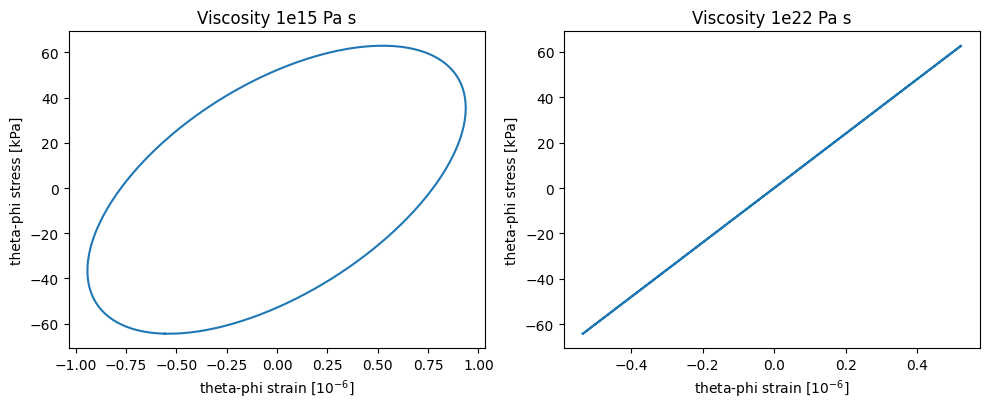

In [5]:
elastic_io = build_io(1.0e22)
point = dict(radii=[0.8 * R], colatitudes=[0.25 * np.pi], longitudes=[0.25 * np.pi])
loop_times = np.linspace(0.0, PERIOD, 401)              # Both ends included, so each loop closes
weights = np.array([1.0, 1.0, 1.0, 2.0, 2.0, 2.0])      # Shear components count twice

figure, axes = plt.subplots(1, 2, figsize=(10, 4.2))
for axis, (label, world) in zip(axes, (("Viscosity 1e15 Pa s", io), ("Viscosity 1e22 Pa s", elastic_io))):
    loop = world.calc_3d_stress_strain(*ORBIT, times=loop_times, **point)
    sigma = loop["stress"][0, 0, 0]     # (time, component) [Pa]
    epsilon = loop["strain"][0, 0, 0]
    axis.plot(epsilon[:, 5] * 1.0e6, sigma[:, 5] / 1.0e3)
    axis.set_title(label)
    axis.set_xlabel("theta-phi strain [$10^{-6}$]")
    axis.set_ylabel("theta-phi stress [kPa]")

    work_per_orbit = np.sum(weights * np.array([np.trapezoid(sigma[:, index], epsilon[:, index]) for index in range(6)]))
    mean_power = world.calc_3d_tides(*ORBIT, radii=np.array(point["radii"]), colatitudes=np.array(point["colatitudes"]),
                                     longitudes=np.array(point["longitudes"]))["heating"][0, 0, 0]
    mean_stress = np.abs(sigma[:-1].mean(axis=0)).max() / np.abs(sigma).max()
    print(f"{label}: mean stress over the orbit {mean_stress:.0e} of the peak; "
          f"work per orbit {work_per_orbit:.4e} J/m^3; mean power times period {mean_power * PERIOD:.4e} J/m^3")
plt.tight_layout()
plt.show()

## Surface Displacement

`calc_3d_displacements` returns the radial, north-south, and east-west displacement on the same kind of grid. Half the difference between the highest and lowest radial position over the orbit is the amplitude of the tidal rise and fall of the surface.

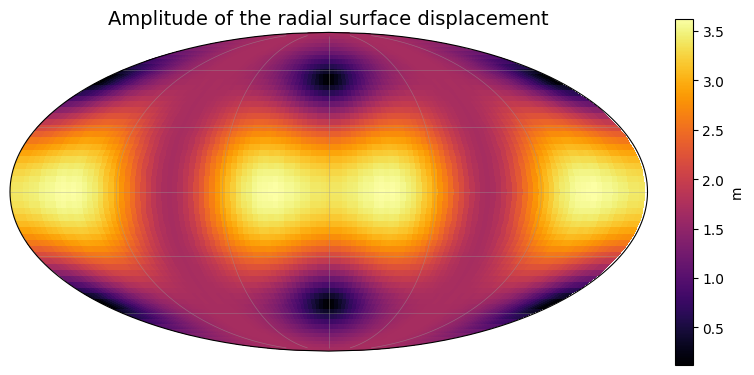

equator at longitude 0: 3.37 m, equator at longitude 90: 1.69 m, north pole: 1.68 m, largest 3.62 m, smallest 0.12 m at latitude 53 and longitude 0


In [6]:
displacement = io.calc_3d_displacements(*ORBIT, radii=[R], colatitudes=colatitudes, longitudes=longitudes,
                                        times=times)
radial = displacement["radial"][0]   # (colatitude, longitude, time) [m]
amplitude = 0.5 * (radial.max(axis=-1) - radial.min(axis=-1))

plot_map(longitudes, colatitudes, amplitude, title="Amplitude of the radial surface displacement", colorbar_label="m")
plt.show()
weakest = np.unravel_index(np.argmin(amplitude), amplitude.shape)
print(f"equator at longitude 0: {amplitude[equator, 0]:.2f} m, equator at longitude 90: {amplitude[equator, 30]:.2f} m, "
      f"north pole: {amplitude[0, 0]:.2f} m, largest {amplitude.max():.2f} m, smallest {amplitude.min():.2f} m at "
      f"latitude {90.0 - np.degrees(colatitudes[weakest[0]]):.0f} and longitude {np.degrees(longitudes[weakest[1]]):.0f}")

The surface rises and falls by up to 3.6 m, most on the equator near the sub-host and anti-host meridians. The amplitude is about 1.7 m at the poles and on the equator at 90 degrees of longitude, and it nearly vanishes, at 0.12 m, near 53 degrees north and south on those two meridians.

## Faster Maps with More Threads

Every grid method takes `num_threads`. The radial solves run first on the calling thread, then the per-point evaluation runs over colatitude rows on that many threads, and the result is identical for any thread count. The default is 1, which suits a process pool whose workers already occupy every core. For one large grid in a session like this one, pass the number of cores.

The cell below times three grids once on one thread and once on every core. It uses degrees 2 and 3 with eccentricity, a non-synchronous spin, and obliquity, so several hundred waves reach every point.

In [7]:
import os
import time

threads = os.cpu_count()   # Every logical core on this machine
io.set_tide_config(min_degree_l=2, max_degree_l=3, eccentricity_truncation=10, obliquity_truncation=2)
state = (N_MOTION, 1.2 * N_MOTION, 0.1, 0.2, A_IO, M_JUP)   # (n, spin, e, obliquity, a, host mass)
map_radii = np.linspace(0.5 * R, 0.99 * R, 10)              # [m]
map_times = np.linspace(0.0, PERIOD, 8, endpoint=False)     # [s]

grids = {
    "Secular heating map": lambda count: io.calc_3d_tides(
        *state, radii=map_radii, colatitudes=colatitudes, longitudes=longitudes, num_threads=count)["heating"],
    "Stress and strain": lambda count: io.calc_3d_stress_strain(
        *state, radii=map_radii, colatitudes=colatitudes, longitudes=longitudes, times=map_times[:2],
        num_threads=count)["stress"],
    "Displacements": lambda count: io.calc_3d_displacements(
        *state, radii=map_radii, colatitudes=colatitudes, longitudes=longitudes, times=map_times,
        num_threads=count)["radial"],
}
print(f"{'grid':20} {'1 thread':>9} {str(threads) + ' threads':>11} {'speedup':>8}  identical")
for label, compute in grids.items():
    results, seconds = {}, {}
    for count in (1, threads):
        start = time.perf_counter()
        results[count] = compute(count)
        seconds[count] = time.perf_counter() - start
    identical = np.array_equal(results[1], results[threads], equal_nan=True)
    print(f"{label:20} {seconds[1]:8.2f}s {seconds[threads]:10.2f}s {seconds[1] / seconds[threads]:7.1f}x  "
          f"{identical}")

# Back to the settings of notebook 9
io.set_tide_config(min_degree_l=2, max_degree_l=2, eccentricity_truncation=2, obliquity_truncation=0)

grid                  1 thread  16 threads  speedup  identical


Secular heating map      0.36s       0.08s     4.3x  True


Stress and strain        0.46s       0.14s     3.3x  True


Displacements            0.34s       0.10s     3.3x  True
